# **IMPORT LIBRARIES AND INPUT FUNCTIONS**

In [1]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import imageio.v2 as imageio
from skimage import color
import random
from scipy import stats

def load_image(file):
    image = imageio.imread(file)
    image = tf.image.convert_image_dtype(image, tf.float32)  # Normalize to [0,1]
    return image

def data_generator(high_files, low_files, batch_size):
    dataset_size = len(high_files)
    for i in range(0, dataset_size, batch_size):
        batch_high = [load_image(f) for f in high_files[i:i+batch_size]]
        batch_low = [load_image(f) for f in low_files[i:i+batch_size]]
        yield np.array(batch_low), np.array(batch_high)

In [10]:
pip install imageio



[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
pip install scikit-image


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 53.6 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.4/226.4 kB 26.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [44]:
pip install tensorflow keras



[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# CREATE DATASET PATHS

In [3]:
base_path = '/kaggle/input/loldataset/LOLdataset'
train_high_path = os.path.join(base_path, 'train/high')
train_low_path = os.path.join(base_path, 'train/low')
val_high_path = os.path.join(base_path, 'val/high')
val_low_path = os.path.join(base_path, 'val/low')

# Load file paths
high_files = sorted(glob.glob(train_high_path + "/*.png"))
low_files = sorted(glob.glob(train_low_path + "/*.png"))
high_val_files = sorted(glob.glob(val_high_path + "/*.png"))
low_val_files = sorted(glob.glob(val_low_path + "/*.png"))

# batch size
batch_size = 16

# Create training dataset


In [4]:
dataset_train = tf.data.Dataset.from_generator(
    lambda: data_generator(high_files, low_files, batch_size),
    output_signature=(
        tf.TensorSpec(shape=(None, None, None, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, None, None, 3), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

# Create validation dataset
dataset_val = tf.data.Dataset.from_generator(
    lambda: data_generator(high_val_files, low_val_files, batch_size),
    output_signature=(
        tf.TensorSpec(shape=(None, None, None, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, None, None, 3), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

CHECKER 

Training samples: 485
Validation samples: 15


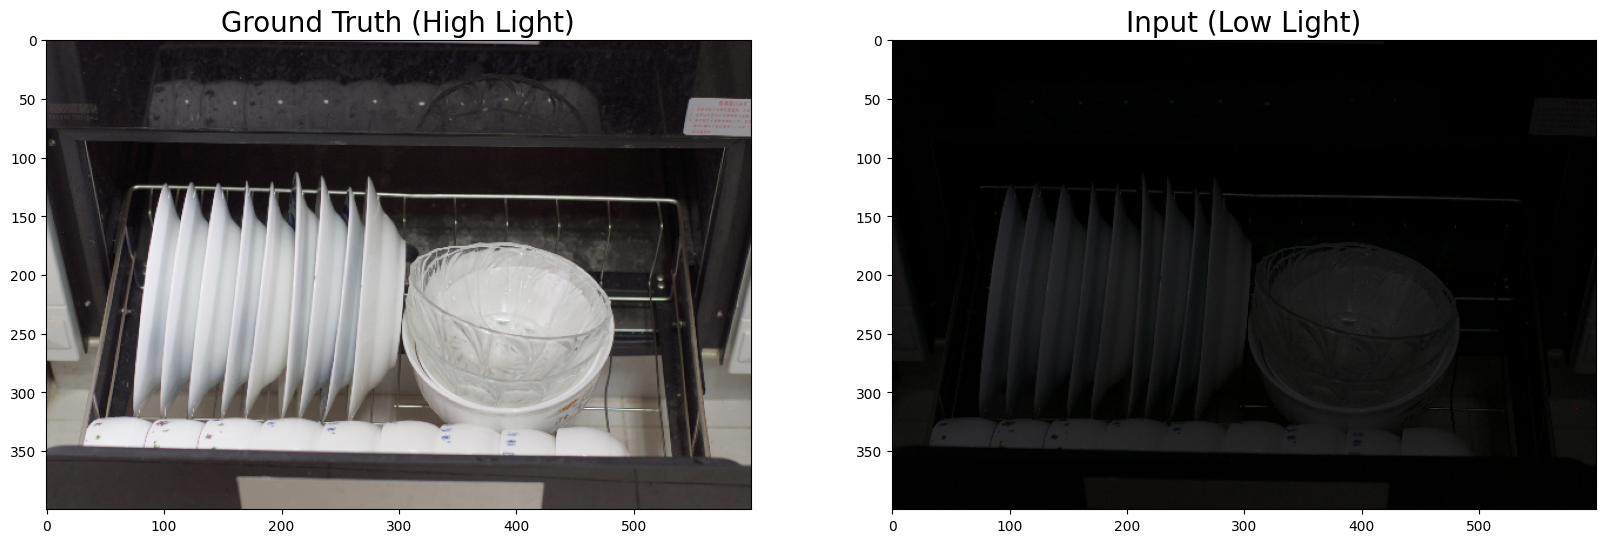

In [5]:
# Print number of training samples
print(f"Training samples: {len(high_files)}")
print(f"Validation samples: {len(high_val_files)}")

# Display a batch sample
for low_batch, high_batch in dataset_train.take(1):
    plt.figure(figsize=(20,10))
    plt.subplot(1,2,1)
    plt.title("Ground Truth (High Light)", fontsize=20)
    plt.imshow(high_batch[1])
    
    plt.subplot(1,2,2)
    plt.title("Input (Low Light)", fontsize=20)
    plt.imshow(low_batch[1])
    plt.savefig('sample_comparison.png')
    plt.show()
    break

**DEFINING EVALUATION FUNCTION**

In [7]:
# Define PSNR metric for evaluation
def psnr_metric(y_true, y_pred):
    return tf.image.psnr(y_true, y_pred, max_val=1.0)


In [8]:
# Load images into memory
def load_images_from_files(file_list):
    images = []
    for file in file_list:
        img = imageio.imread(file)
        # Convert to float32 and normalize to [0,1]
        img = img.astype('float32') / 255.0
        images.append(img)
    return np.array(images)

# Load training images
print("Loading training images...")
high_images = load_images_from_files(high_files)
low_images = load_images_from_files(low_files)

# Load validation images
print("Loading validation images...")
high_val = load_images_from_files(high_val_files)
low_val = load_images_from_files(low_val_files)

# Assign to normalized variables (images are already normalized in the load function)
low_train_norm = low_images
high_train_norm = high_images
low_val_norm = low_val
high_val_norm = high_val

# Only proceed if images were successfully loaded
if len(high_images) > 0 and len(low_images) > 0:
    # Removed additional normalization step since images are already in [0,1]
    
    # If no validation data is available, use a portion of training data for validation
    if len(high_val) == 0 or len(low_val) == 0:
        print("No validation data available. Using a portion of training data for validation.")
        val_split = 0.1
        val_indices = np.random.choice(len(high_images), int(len(high_images) * val_split), replace=False)
        
        high_val_norm = high_train_norm[val_indices]
        low_val_norm = low_train_norm[val_indices]
        
        # Remove validation samples from training
        train_mask = np.ones(len(high_images), dtype=bool)
        train_mask[val_indices] = False
        high_train_norm = high_train_norm[train_mask]
        low_train_norm = low_train_norm[train_mask]

    # Print shapes to verify
    print("Low train shape:", low_train_norm.shape)
    print("High train shape:", high_train_norm.shape)
    print("Low val shape:", low_val_norm.shape)
    print("High val shape:", high_val_norm.shape)

# After this fix, the range of the training and validation data should remain [0, 1]
print("Training data range:", low_train_norm.min(), low_train_norm.max())
print("Validation data range:", low_val_norm.min(), low_val_norm.max())


Loading training images...
Loading validation images...
Low train shape: (485, 400, 600, 3)
High train shape: (485, 400, 600, 3)
Low val shape: (15, 400, 600, 3)
High val shape: (15, 400, 600, 3)
Training data range: 0.0 1.0
Validation data range: 0.0 1.0


**DATA PREPROCESSING**

In [9]:
# After this fix, the range of the training and validation data should remain [0, 1]
print("Training data range:", low_train_norm.min(), low_train_norm.max())
print("Validation data range:", low_val_norm.min(), low_val_norm.max())


Training data range: 0.0 1.0
Validation data range: 0.0 1.0


# EXPOLATORY DATA ANALYSIS

In [10]:
# 1. Analyze Dataset Size and Properties
print("\n--- Dataset Overview ---")
print(f"Training pairs: {len(high_files)}")
print(f"Validation pairs: {len(high_val_files)}")

# 2. Analyze Image Dimensions
image_heights = []
image_widths = []
image_channels = []

for file in high_files[:20]:  # Sample first 20 images for speed
    img = imageio.imread(file)
    image_heights.append(img.shape[0])
    image_widths.append(img.shape[1])
    image_channels.append(img.shape[2] if len(img.shape) > 2 else 1)

print("\n--- Image Dimensions ---")
print(f"Height: min={min(image_heights)}, max={max(image_heights)}, median={np.median(image_heights)}")
print(f"Width: min={min(image_widths)}, max={max(image_widths)}, median={np.median(image_widths)}")
print(f"Channels: {set(image_channels)}")


--- Dataset Overview ---
Training pairs: 485
Validation pairs: 15

--- Image Dimensions ---
Height: min=400, max=400, median=400.0
Width: min=600, max=600, median=600.0
Channels: {3}


In [11]:
# 3. Analyze Brightness Distribution
def analyze_image_stats(files, title, sample_size=15):
    # Sample random images for analysis
    sample_files = random.sample(files, min(sample_size, len(files)))
    
    avg_brightness = []
    std_brightness = []
    histograms = []
    
    for file in sample_files:
        img = imageio.imread(file)
        
        # Convert to grayscale for brightness analysis
        if len(img.shape) == 3:
            gray = color.rgb2gray(img)
        else:
            gray = img / 255.0
            
        avg_brightness.append(np.mean(gray))
        std_brightness.append(np.std(gray))
        
        # Calculate histogram
        hist, _ = np.histogram(gray.flatten(), bins=50, range=(0, 1))
        histograms.append(hist)
    
    return {
        'files': sample_files,
        'avg_brightness': avg_brightness,
        'std_brightness': std_brightness,
        'histograms': histograms,
        'title': title
    }


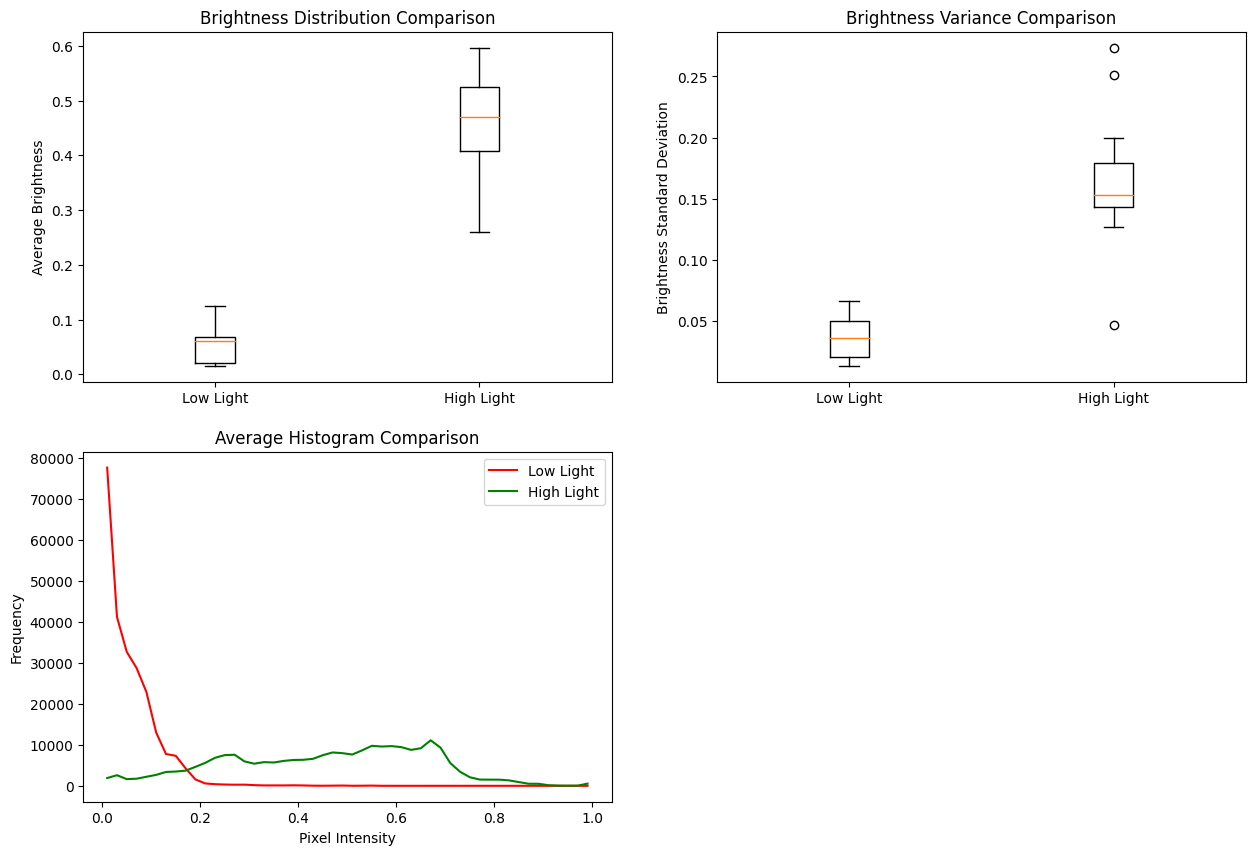

In [12]:
# Analyze low and high light images
low_stats = analyze_image_stats(low_files, "Low Light")
high_stats = analyze_image_stats(high_files, "High Light", sample_size=len(low_stats['files']))

# 4. Visualize brightness distribution
plt.figure(figsize=(15, 10))

# Average brightness comparison
plt.subplot(2, 2, 1)
plt.boxplot([low_stats['avg_brightness'], high_stats['avg_brightness']])
plt.xticks([1, 2], ['Low Light', 'High Light'])
plt.ylabel('Average Brightness')
plt.title('Brightness Distribution Comparison')

# Standard deviation comparison
plt.subplot(2, 2, 2)
plt.boxplot([low_stats['std_brightness'], high_stats['std_brightness']])
plt.xticks([1, 2], ['Low Light', 'High Light'])
plt.ylabel('Brightness Standard Deviation')
plt.title('Brightness Variance Comparison')

# Average histograms
plt.subplot(2, 2, 3)
avg_low_hist = np.mean(low_stats['histograms'], axis=0)
avg_high_hist = np.mean(high_stats['histograms'], axis=0)
bin_centers = np.linspace(0.01, 0.99, len(avg_low_hist))
plt.plot(bin_centers, avg_low_hist, 'r-', label='Low Light')
plt.plot(bin_centers, avg_high_hist, 'g-', label='High Light')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Average Histogram Comparison')
plt.legend()


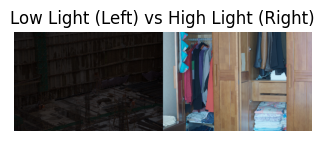

In [13]:
# 5. Show sample image pairs
plt.subplot(2, 2, 4)
sample_idx = np.random.randint(len(low_stats['files']))
low_img = imageio.imread(low_stats['files'][sample_idx])
high_img = imageio.imread(high_stats['files'][sample_idx])

# Create a side-by-side comparison
comparison = np.hstack((low_img, high_img))
plt.imshow(comparison)
plt.axis('off')
plt.title('Low Light (Left) vs High Light (Right)')

plt.tight_layout()
plt.savefig('brightness_analysis.png')
plt.show()

In [15]:
# 6. Channel Distribution Analysis
def analyze_channel_distribution(files, title, sample_size=15):
    sample_files = random.sample(files, min(sample_size, len(files)))
    
    channel_means = {
        'R': [],
        'G': [],
        'B': []
    }
    
    for file in sample_files:
        img = imageio.imread(file)
        
        if len(img.shape) == 3:
            r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]
            channel_means['R'].append(np.mean(r) / 255.0)
            channel_means['G'].append(np.mean(g) / 255.0)
            channel_means['B'].append(np.mean(b) / 255.0)
    
    return channel_means, title

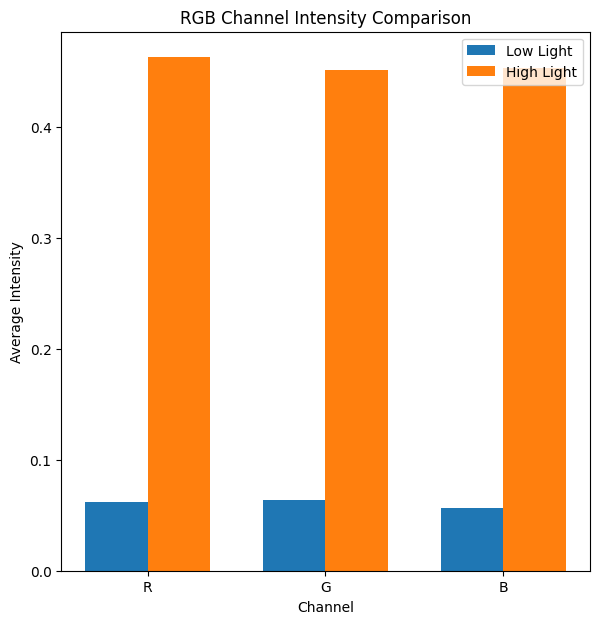

In [16]:
# Analyze RGB channels
low_channels, low_title = analyze_channel_distribution(low_files, "Low Light")
high_channels, high_title = analyze_channel_distribution(high_files, "High Light")

# Visualize channel distributions
plt.figure(figsize=(15, 7))

# Channel means comparison
channel_names = ['R', 'G', 'B']
low_means = [np.mean(low_channels[ch]) for ch in channel_names]
high_means = [np.mean(high_channels[ch]) for ch in channel_names]

x = np.arange(len(channel_names))
width = 0.35

plt.subplot(1, 2, 1)
plt.bar(x - width/2, low_means, width, label='Low Light')
plt.bar(x + width/2, high_means, width, label='High Light')
plt.xlabel('Channel')
plt.ylabel('Average Intensity')
plt.title('RGB Channel Intensity Comparison')
plt.xticks(x, channel_names)
plt.legend()

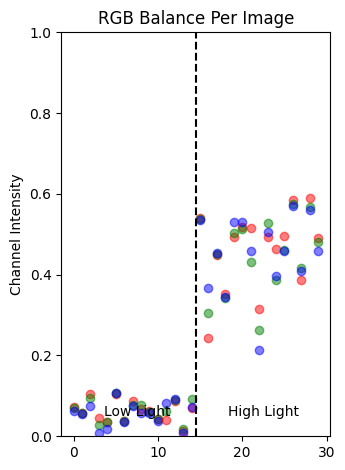

In [17]:
# Channel balance
plt.subplot(1, 2, 2)
for i, pair in enumerate(zip(low_channels['R'], low_channels['G'], low_channels['B'])):
    plt.scatter(i, pair[0], color='red', alpha=0.5)
    plt.scatter(i, pair[1], color='green', alpha=0.5)
    plt.scatter(i, pair[2], color='blue', alpha=0.5)
    
for i, pair in enumerate(zip(high_channels['R'], high_channels['G'], high_channels['B'])):
    plt.scatter(i+len(low_channels['R']), pair[0], color='red', alpha=0.5)
    plt.scatter(i+len(low_channels['G']), pair[1], color='green', alpha=0.5)
    plt.scatter(i+len(low_channels['B']), pair[2], color='blue', alpha=0.5)

plt.axvline(x=len(low_channels['R'])-0.5, color='black', linestyle='--')
plt.text(len(low_channels['R'])/2, 0.05, 'Low Light', horizontalalignment='center')
plt.text(len(low_channels['R'])+len(high_channels['R'])/2, 0.05, 'High Light', horizontalalignment='center')
plt.ylabel('Channel Intensity')
plt.title('RGB Balance Per Image')
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig('channel_analysis.png')
plt.show()



--- Calculating SSIM between image pairs ---
Processed 1/20 image pairs for SSIM
Processed 6/20 image pairs for SSIM
Processed 11/20 image pairs for SSIM
Processed 16/20 image pairs for SSIM


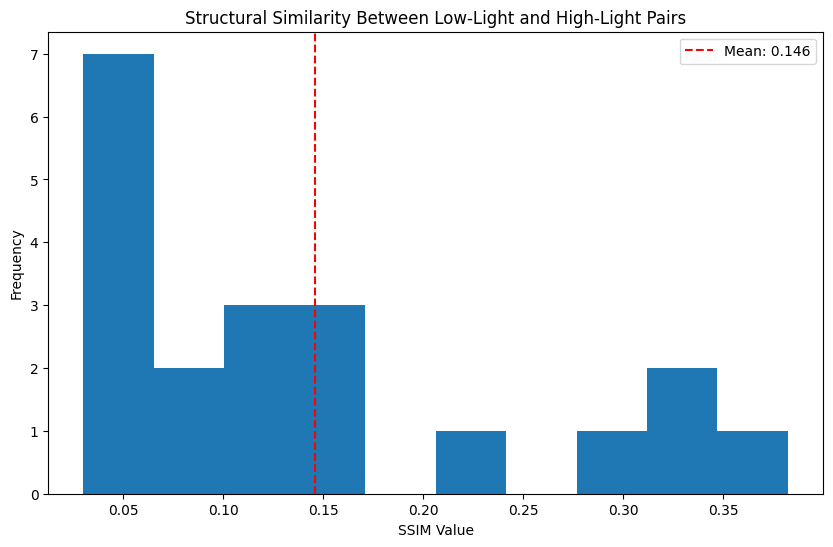

In [18]:
# 7. Analyze Structural Similarity (SSIM) between low and high pairs
def calculate_ssim(low_file, high_file):
    low_img = cv2.imread(low_file)
    high_img = cv2.imread(high_file)
    
    # Ensure images are the same size
    if low_img.shape != high_img.shape:
        high_img = cv2.resize(high_img, (low_img.shape[1], low_img.shape[0]))
    
    # Convert to grayscale
    low_gray = cv2.cvtColor(low_img, cv2.COLOR_BGR2GRAY)
    high_gray = cv2.cvtColor(high_img, cv2.COLOR_BGR2GRAY)
    
    # Calculate SSIM - using the correct function name based on OpenCV version
    try:
        # For newer versions of OpenCV
        ssim = cv2.SSIM(low_gray, high_gray)[0]  # [0] to get the scalar value
    except AttributeError:
        try:
            # For another common version
            ssim = cv2.ssim(low_gray, high_gray)
        except AttributeError:
            try:
                # For newer OpenCV versions
                ssim = cv2.quality.QualitySSIM_compute(low_gray, high_gray)[0]
            except AttributeError:
                # If all fails, use scikit-image's SSIM
                from skimage.metrics import structural_similarity as skssim
                ssim = skssim(low_gray, high_gray)
    
    return ssim

# Alternatively, use skimage's SSIM directly (more reliable across environments)
def calculate_ssim_skimage(low_file, high_file):
    from skimage.metrics import structural_similarity as skssim
    from skimage import io
    
    # Read images
    low_img = io.imread(low_file)
    high_img = io.imread(high_file)
    
    # Convert to grayscale if needed
    if len(low_img.shape) == 3:
        from skimage.color import rgb2gray
        low_gray = rgb2gray(low_img)
        high_gray = rgb2gray(high_img)
    else:
        low_gray = low_img
        high_gray = high_img
    
    # Calculate SSIM
    ssim = skssim(low_gray, high_gray, data_range=high_gray.max() - high_gray.min())
    return ssim

# Use the skimage version for more reliability
print("\n--- Calculating SSIM between image pairs ---")
ssim_values = []
for i in range(min(20, len(low_files))):  # Analyze a subset for speed
    try:
        ssim = calculate_ssim_skimage(low_files[i], high_files[i])
        ssim_values.append(ssim)
        if i % 5 == 0:  # Print progress every 5 images
            print(f"Processed {i+1}/20 image pairs for SSIM")
    except Exception as e:
        print(f"Error calculating SSIM for pair {i}: {e}")
        continue

# Only plot if we have SSIM values
if ssim_values:
    plt.figure(figsize=(10, 6))
    plt.hist(ssim_values, bins=10)
    plt.xlabel('SSIM Value')
    plt.ylabel('Frequency')
    plt.title('Structural Similarity Between Low-Light and High-Light Pairs')
    plt.axvline(np.mean(ssim_values), color='r', linestyle='--', label=f'Mean: {np.mean(ssim_values):.3f}')
    plt.legend()
    plt.savefig('ssim_analysis.png')
    plt.show()
else:
    print("No SSIM values were calculated successfully.")

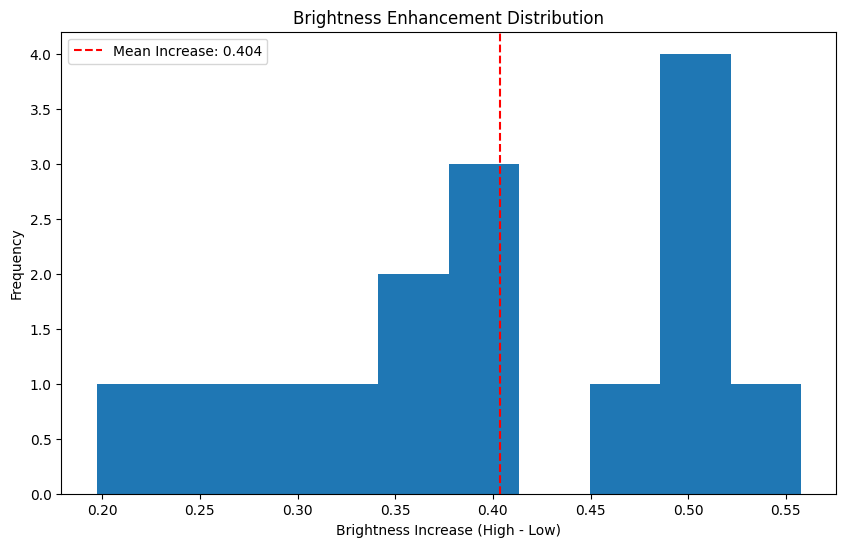

In [20]:
# 8. Analyze enhancement difficulty by plotting brightness difference
brightness_increase = []
for i in range(min(len(low_stats['avg_brightness']), len(high_stats['avg_brightness']))):
    brightness_increase.append(high_stats['avg_brightness'][i] - low_stats['avg_brightness'][i])

plt.figure(figsize=(10, 6))
plt.hist(brightness_increase, bins=10)
plt.xlabel('Brightness Increase (High - Low)')
plt.ylabel('Frequency')
plt.title('Brightness Enhancement Distribution')
plt.axvline(np.mean(brightness_increase), color='r', linestyle='--', 
           label=f'Mean Increase: {np.mean(brightness_increase):.3f}')
plt.legend()
plt.savefig('brightness_increase.png')
plt.show()

In [21]:
# 9. Summary statistics
print("\n--- Summary Statistics ---")
print(f"Low-light average brightness: {np.mean(low_stats['avg_brightness']):.3f} ± {np.std(low_stats['avg_brightness']):.3f}")
print(f"High-light average brightness: {np.mean(high_stats['avg_brightness']):.3f} ± {np.std(high_stats['avg_brightness']):.3f}")
print(f"Average brightness increase: {np.mean(brightness_increase):.3f} ± {np.std(brightness_increase):.3f}")
try:
    print(f"Average SSIM between low-high pairs: {np.mean(ssim_values):.3f} ± {np.std(ssim_values):.3f}")
except:
    print("SSIM calculation was skipped or failed")



--- Summary Statistics ---
Low-light average brightness: 0.054 ± 0.032
High-light average brightness: 0.457 ± 0.098
Average brightness increase: 0.404 ± 0.103
Average SSIM between low-high pairs: 0.146 ± 0.108


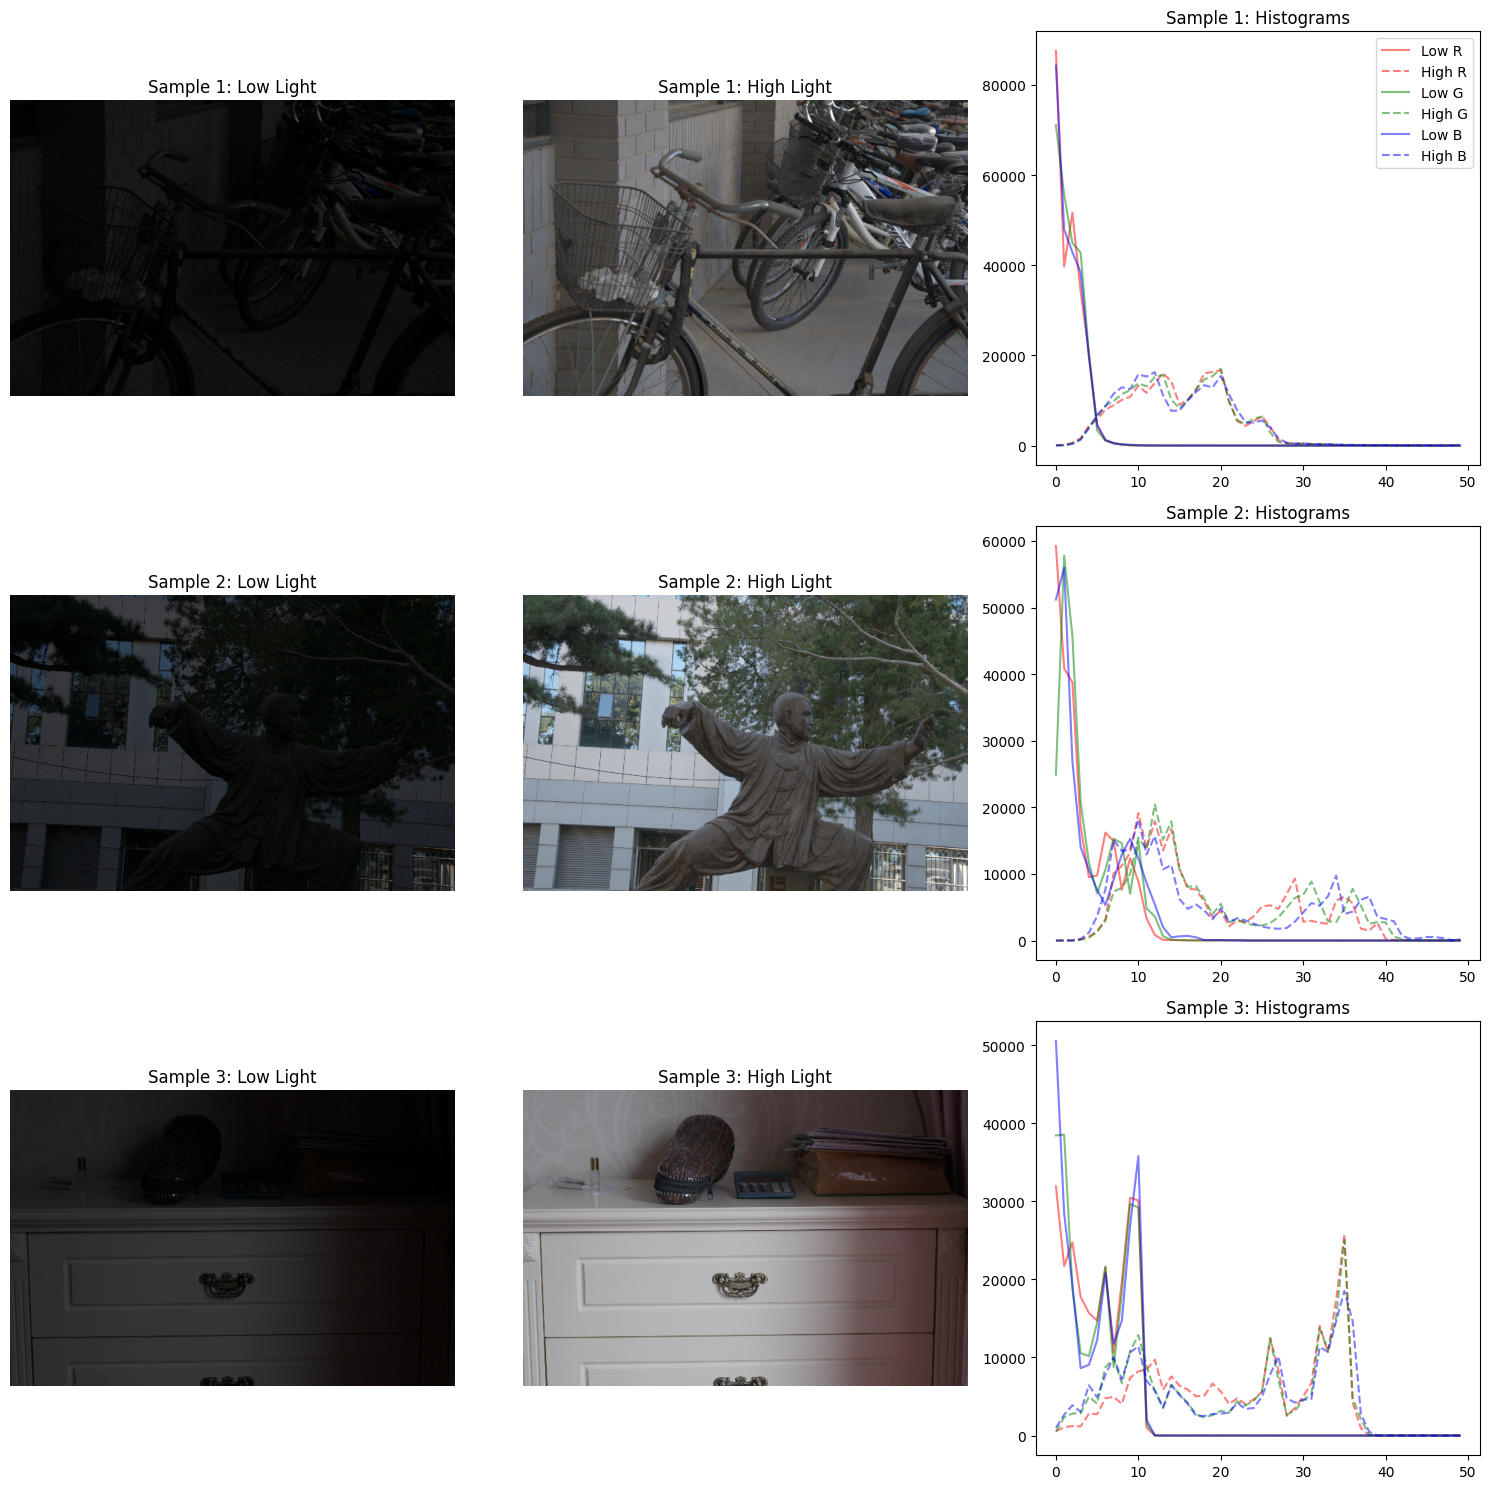

In [22]:
# 10. Visualize more sample pairs with histograms
plt.figure(figsize=(15, 15))
num_samples = min(3, len(low_files))

for i in range(num_samples):
    idx = np.random.randint(len(low_files))
    low_img = imageio.imread(low_files[idx])
    high_img = imageio.imread(high_files[idx])
    
    # Plot images
    plt.subplot(num_samples, 3, i*3+1)
    plt.imshow(low_img)
    plt.title(f'Sample {i+1}: Low Light')
    plt.axis('off')
    
    plt.subplot(num_samples, 3, i*3+2)
    plt.imshow(high_img)
    plt.title(f'Sample {i+1}: High Light')
    plt.axis('off')
    
    # Plot histograms side by side
    plt.subplot(num_samples, 3, i*3+3)
    
    if len(low_img.shape) == 3:
        # RGB histograms
        color_channels = ['r', 'g', 'b']
        for j, col in enumerate(color_channels):
            hist_low, _ = np.histogram(low_img[:,:,j].flatten(), bins=50, range=(0, 255))
            hist_high, _ = np.histogram(high_img[:,:,j].flatten(), bins=50, range=(0, 255))
            plt.plot(hist_low, color=col, linestyle='-', alpha=0.5, label=f'Low {col.upper()}')
            plt.plot(hist_high, color=col, linestyle='--', alpha=0.5, label=f'High {col.upper()}')
    else:
        # Grayscale histograms
        hist_low, _ = np.histogram(low_img.flatten(), bins=50, range=(0, 255))
        hist_high, _ = np.histogram(high_img.flatten(), bins=50, range=(0, 255))
        plt.plot(hist_low, 'k-', alpha=0.5, label='Low')
        plt.plot(hist_high, 'k--', alpha=0.5, label='High')
    
    plt.title(f'Sample {i+1}: Histograms')
    if i == 0:  # Only show legend for the first plot to save space
        plt.legend()

plt.tight_layout()
plt.savefig('sample_pairs_with_histograms.png')
plt.show()

In [106]:
print("Training data range:", low_train_norm.min(), low_train_norm.max())
print("Validation data range:", low_val_norm.min(), low_val_norm.max())

Training data range: 0.0 1.0
Validation data range: 0.0 1.0


**MODEL TRAINING**

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ img (InputLayer)          │ (None, None, None, 3)  │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, None, None, 32) │            896 │ img[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, None, None, 32) │          9,248 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, None, None, 32) │          9,248 │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, None, None, 32) │          9,248 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, None, None, 32) │              0 │ conv2d_2[0][0],        │
│                           │                        │                │ conv2d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, None, None, 32) │          9,248 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, None, None, 32) │              0 │ conv2d_1[0][0],        │
│                           │                        │                │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, None, None, 32) │          9,248 │ add_1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (Add)               │ (None, None, None, 32) │              0 │ conv2d[0][0],          │
│                           │                        │                │ conv2d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, None, None, 3)  │            867 │ add_2[0][0]            │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 48,003 (187.51 KB)

 Trainable params: 48,003 (187.51 KB)

 Non-trainable params: 0 (0.00 B)

X sample shape: (4, 400, 600, 3)
Y sample shape: (4, 400, 600, 3)
Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


121/121 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - loss: 0.0393 - psnr_metric: 14.9333 - val_loss: 0.0341 - val_psnr_metric: 15.7039
Epoch 2/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - loss: 0.0275 - psnr_metric: 16.7452 - val_loss: 0.0276 - val_psnr_metric: 16.6490
Epoch 3/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - loss: 0.0293 - psnr_metric: 16.4592 - val_loss: 0.0278 - val_psnr_metric: 16.7787
Epoch 4/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - loss: 0.0274 - psnr_metric: 16.8063 - val_loss: 0.0248 - val_psnr_metric: 17.3131
Epoch 5/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - loss: 0.0280 - psnr_metric: 17.0257 - val_loss: 0.0254 - val_psnr_metric: 16.9080
Epoch 6/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - loss: 0.0264 - psnr_metric: 17.1954 - val_loss: 0.0252 - val_psnr_metric: 17.4041
Epoch 7/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - loss: 0.0270 - psnr_metric: 17.4381 - val_loss: 0.0240 - val_psnr_metric: 17.6366
Epoch 8/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/ste

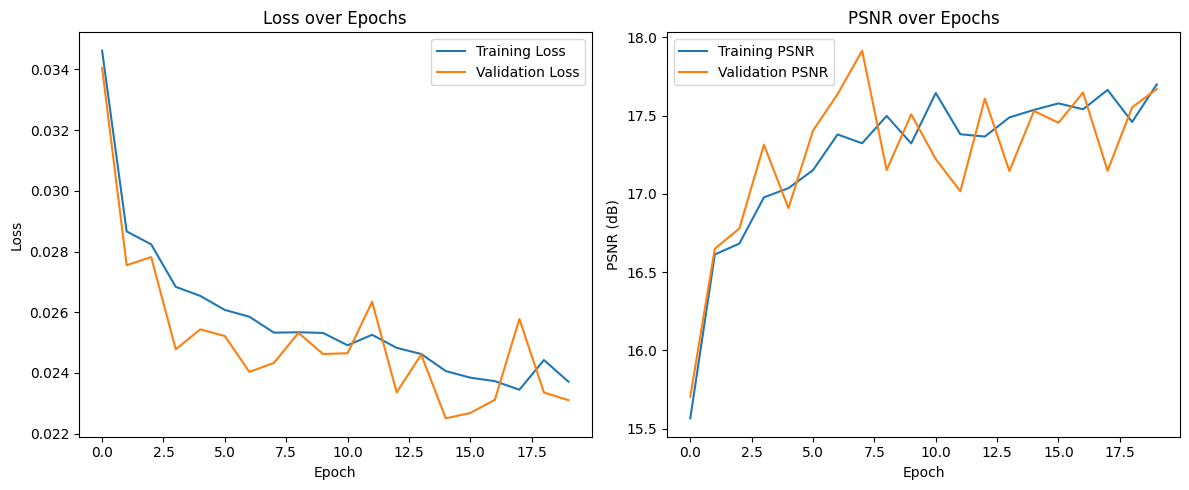

In [23]:

    # Create a custom data generator
    class ImageDenoiseGenerator(tf.keras.utils.Sequence):
        def __init__(self, X, y, batch_size=4):
            self.X = X
            self.y = y
            self.batch_size = batch_size

        def __len__(self):
            return len(self.X) // self.batch_size

        def __getitem__(self, idx):
            # Get batch indices
            start_idx = idx * self.batch_size
            end_idx = min((idx + 1) * self.batch_size, len(self.X))

            # Extract batch
            X_batch = self.X[start_idx:end_idx]
            y_batch = self.y[start_idx:end_idx]

            # Return full RGB images
            return X_batch, y_batch

    # Create model
    activation = 'relu'
    padding = 'same'
    kernel = (3,3)

    inputs = keras.Input(shape=(None, None, 3), name='img')

    # Creating model architecture
    layer1 = layers.Conv2D(32, kernel, activation=activation, padding=padding)(inputs)
    layer2 = layers.Conv2D(32, kernel, activation=activation, padding=padding)(layer1)
    layer3 = layers.Conv2D(32, kernel, activation=activation, padding=padding)(layer2)
    layer4 = layers.Conv2D(32, kernel, activation=activation, padding=padding)(layer3)
    layer5 = layers.add([layer3, layer4])  # Combination of 2 layers
    layer6 = layers.Conv2D(32, kernel, activation=activation, padding=padding)(layer5)
    layer7 = layers.add([layer2, layer6])  # combination of 2 layers
    layer8 = layers.Conv2D(32, kernel, activation=activation, padding=padding)(layer7)
    final = layers.add([layer1, layer8])

    # For output we will use sigmoid activation for values between [0,1]
    # Output 3 channels for RGB
    outLayer = layers.Conv2D(3, kernel, activation='sigmoid', padding=padding)(final)

    denoisingModel = keras.Model(inputs, outLayer)

    # Compile the model
    denoisingModel.compile(
        optimizer='adam',
        loss='mse',
        metrics=[psnr_metric]
    )

    # Print model summary
    denoisingModel.summary()

    # Create training generator
    training_generator = ImageDenoiseGenerator(low_train_norm, high_train_norm, batch_size=4)
    validation_generator = ImageDenoiseGenerator(low_val_norm, high_val_norm, batch_size=4)

    # Verify generator output
    X_sample, y_sample = training_generator[0]
    print("X sample shape:", X_sample.shape)
    print("Y sample shape:", y_sample.shape)

    # Train model
    history = denoisingModel.fit(
        training_generator,
        validation_data=validation_generator,
        epochs=20,
        verbose=1
    )

    # Plot training history
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['psnr_metric'], label='Training PSNR')
    plt.plot(history.history['val_psnr_metric'], label='Validation PSNR')
    plt.title('PSNR over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('PSNR (dB)')
    plt.legend()
    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()


**VALIDATION AND TESTING**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


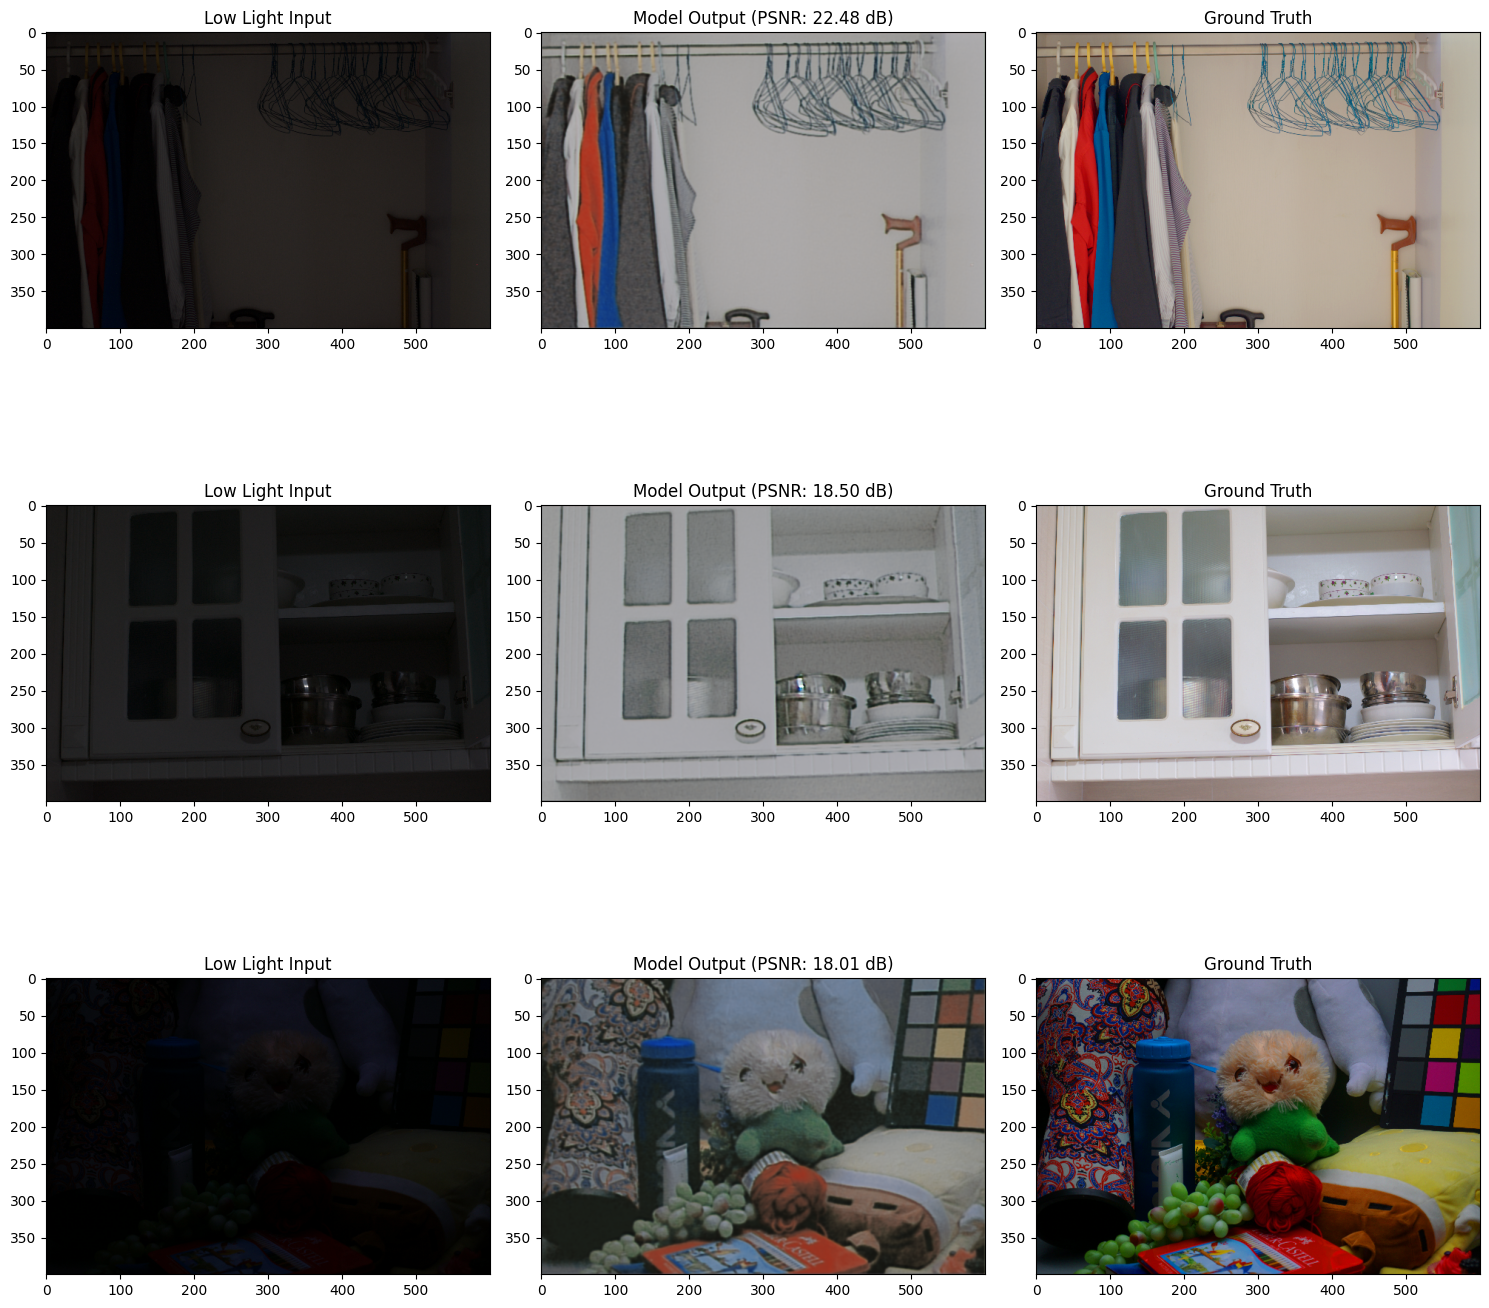

Validation PSNR: 17.87 ± 3.04 dB
Model saved to /kaggle/working/denoising_model.h5
Results saved to working directory


In [24]:
# Visualize results on validation data
def visualize_results(model, low_images, high_images, num_samples=3):
    plt.figure(figsize=(15, 5*num_samples))
    
    # Select distinct random indices
    indices = np.random.choice(len(low_images), size=min(num_samples, len(low_images)), replace=False)
    
    for i, idx in enumerate(indices):
        # Get input and ground truth
        low_img = low_images[idx:idx+1]
        high_img = high_images[idx:idx+1]
        
        # Generate prediction
        pred = model.predict(low_img)
        
        # Convert back for visualization
        low_img_vis = low_img[0]
        high_img_vis = high_img[0]
        pred_vis = pred[0]
        
        # Calculate PSNR for this sample
        psnr_value = tf.image.psnr(high_img, pred, max_val=1.0).numpy()[0]
        
        # Display
        plt.subplot(num_samples, 3, i*3+1)
        plt.title("Low Light Input")
        plt.imshow(low_img_vis)
        
        plt.subplot(num_samples, 3, i*3+2)
        plt.title(f"Model Output (PSNR: {psnr_value:.2f} dB)")
        plt.imshow(pred_vis)
        
        plt.subplot(num_samples, 3, i*3+3)
        plt.title("Ground Truth")
        plt.imshow(high_img_vis)
    
    plt.tight_layout()
    plt.savefig('results_comparison.png')
    plt.show()

# Calculate PSNR for validation set
def calculate_psnr_for_dataset(model, low_images, high_images):
    psnr_values = []
    
    for i in range(len(low_images)):
        # Get input and ground truth
        low_img = low_images[i:i+1]
        high_img = high_images[i:i+1]
        
        # Generate prediction
        pred = model.predict(low_img, verbose=0)
        
        # Calculate PSNR
        psnr = tf.image.psnr(high_img, pred, max_val=1.0).numpy()[0]
        psnr_values.append(psnr)
    
    return np.mean(psnr_values), np.std(psnr_values)

# Visualize some validation results
visualize_results(denoisingModel, low_val_norm, high_val_norm, num_samples=3)

# Calculate and print PSNR metrics
mean_psnr, std_psnr = calculate_psnr_for_dataset(denoisingModel, low_val_norm, high_val_norm)
print(f"Validation PSNR: {mean_psnr:.2f} ± {std_psnr:.2f} dB")

# Save the model
denoisingModel.save('/kaggle/working/denoising_model.h5')
print("Model saved to /kaggle/working/denoising_model.h5")

# Save a sample output for visualization in the Kaggle notebook output
# Use distinct samples for these visualizations too
sample_indices = np.random.choice(len(low_val_norm), size=min(5, len(low_val_norm)), replace=False)

for i, idx in enumerate(sample_indices):
    plt.figure(figsize=(15, 5))
    
    # Get a sample
    low_img = low_val_norm[idx:idx+1]
    high_img = high_val_norm[idx:idx+1]
    
    # Generate prediction
    pred = denoisingModel.predict(low_img, verbose=0)
    
    # Display
    plt.subplot(1, 3, 1)
    plt.title("Low Light Input")
    plt.imshow(low_img[0])
    
    plt.subplot(1, 3, 2)
    plt.title("Model Output")
    plt.imshow(pred[0])
    
    plt.subplot(1, 3, 3)
    plt.title("Ground Truth")
    plt.imshow(high_img[0])
    
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/result_sample_{i}.png')
    plt.close()

print("Results saved to working directory")